In [ ]:
# Import libraries
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

warnings.filterwarnings("ignore")

In [ ]:
# load dataset
data_path = "retail_store_inventory.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [ ]:
#explore the dataset
df.info()
df.info()

# Display basic statistics for numerical columns
df.describe()

# Check for missing values
print("Missing values:")
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 8.4 MB
<class 'pan

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

In [ ]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

print("Columns after cleaning:")
print(df.columns.tolist())

# Define the target column
target_col = "Units_Sold"

if target_col not in df.columns:
    print("Target column not found:", target_col)
    print("Available columns:")
    print(df.columns.tolist())
    raise ValueError("Please check the target column name.")
else:
    print("Target variable:", target_col)

Columns after cleaning:
['Date', 'Store_ID', 'Product_ID', 'Category', 'Region', 'Inventory_Level', 'Units_Sold', 'Units_Ordered', 'Demand_Forecast', 'Price', 'Discount', 'Weather_Condition', 'Holiday_Promotion', 'Competitor_Pricing', 'Seasonality']
Target variable: Units_Sold


In [ ]:
# data preparation  
# Remove duplicated rows
df = df.drop_duplicates()

# Remove rows with missing target value
df = df.dropna(subset=[target_col])

# Keep only valid target values
df = df[df[target_col] >= 0]

print("Dataset shape after basic cleaning:", df.shape)

Dataset shape after basic cleaning: (73100, 15)


Q1: 49.0
Q3: 203.0
IQR: 154.0
Lower bound: -182.0
Upper bound: 434.0
Number of outliers: 715


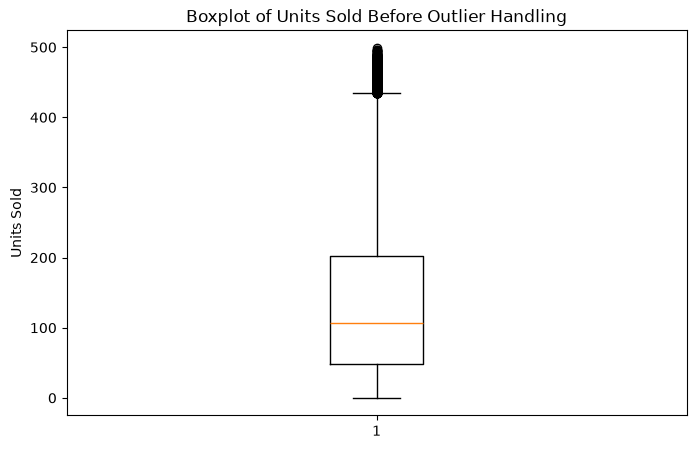

Rows before outlier handling: 73100
Rows after outlier handling: 72385
Removed rows: 715


In [ ]:
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]
print("Number of outliers:", outliers.shape[0])

# Visualize the distribution of the target variable before outlier handling
plt.figure(figsize=(8, 5))
plt.boxplot(df[target_col])
plt.title("Boxplot of Units Sold Before Outlier Handling")
plt.ylabel("Units Sold")
plt.show()

# Visualize the distribution of the target variable after outlier handling
before_rows = df.shape[0]

df = df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)]

after_rows = df.shape[0]

print("Rows before outlier handling:", before_rows)
print("Rows after outlier handling:", after_rows)
print("Removed rows:", before_rows - after_rows)

In [ ]:
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["DayOfWeek"] = df["Date"].dt.dayofweek
    df["Quarter"] = df["Date"].dt.quarter
    df["Is_Weekend"] = df["DayOfWeek"].apply(lambda x: 1 if x >= 5 else 0)

    df = df.drop(columns=["Date"])

df.head()

# Feature engineering
if "Price" in df.columns and "Discount" in df.columns:
    df["Discounted_Price"] = df["Price"] * (1 - df["Discount"] / 100)

if "Price" in df.columns and "Competitor_Pricing" in df.columns:
    df["Price_Difference"] = df["Price"] - df["Competitor_Pricing"]

if "Inventory_Level" in df.columns:
    df["Inventory_Level_Log"] = np.log1p(df["Inventory_Level"])

df.head()

,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Sold,Units_Ordered,Demand_Forecast,Price,Discount,...,Seasonality,Year,Month,Day,DayOfWeek,Quarter,Is_Weekend,Discounted_Price,Price_Difference,Inventory_Level_Log
0,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,...,Autumn,2022,1,1,5,1,1,26.800,3.81,5.446737
1,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,...,Autumn,2022,1,1,5,1,1,50.408,-3.15,5.323010
2,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,...,Summer,2022,1,1,5,1,1,25.191,-3.33,4.634729
3,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,...,Autumn,2022,1,1,5,1,1,29.448,-2.02,6.152733
4,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,...,Summer,2022,1,1,5,1,1,73.640,4.69,5.117994


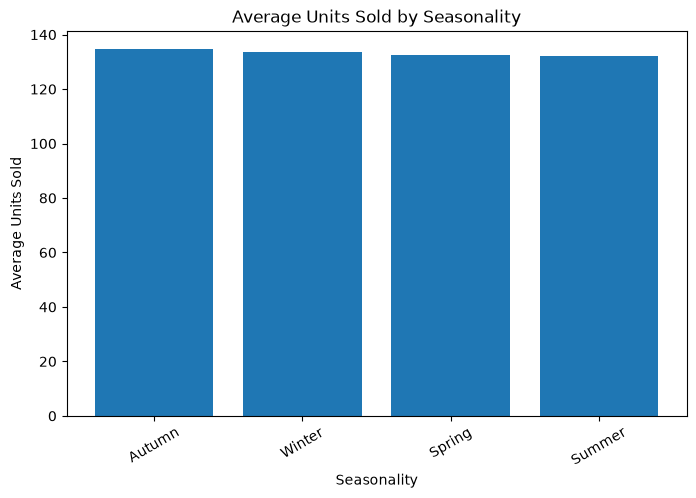

In [ ]:
if "Price" in df.columns and "Discount" in df.columns:
    df["Discounted_Price"] = df["Price"] * (1 - df["Discount"] / 100)

if "Price" in df.columns and "Competitor_Pricing" in df.columns:
    df["Price_Difference"] = df["Price"] - df["Competitor_Pricing"]

if "Inventory_Level" in df.columns:
    df["Inventory_Level_Log"] = np.log1p(df["Inventory_Level"])

df.head()

if "Seasonality" in df.columns:
    season_sales = df.groupby("Seasonality")[target_col].mean().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    plt.bar(season_sales.index.astype(str), season_sales.values)
    plt.title("Average Units Sold by Seasonality")
    plt.xlabel("Seasonality")
    plt.ylabel("Average Units Sold")
    plt.xticks(rotation=30)
    plt.show()

In [ ]:
leakage_cols = []

for col in ["Demand_Forecast"]:
    if col in df.columns:
        leakage_cols.append(col)

df = df.drop(columns=leakage_cols, errors="ignore")

print("Dropped leakage columns:", leakage_cols)

Dropped leakage columns: ['Demand_Forecast']


In [ ]:
X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

#
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

X shape: (72385, 21)
y shape: (72385,)
Numeric features:
['Inventory_Level', 'Units_Ordered', 'Price', 'Discount', 'Holiday_Promotion', 'Competitor_Pricing', 'Is_Weekend', 'Discounted_Price', 'Price_Difference', 'Inventory_Level_Log']

Categorical features:
['Store_ID', 'Product_ID', 'Category', 'Region', 'Weather_Condition', 'Seasonality']


In [ ]:
# processing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    sparse_threshold=0
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (57908, 21)
X_test: (14477, 21)
y_train: (57908,)
y_test: (14477,)


In [ ]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42,
        max_depth=10
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_estimators=100,
        max_depth=15,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3
    )
}

Training model: Linear Regression
MAE: 68.15115646874595
MSE: 7466.278673339487
RMSE: 86.40763087447478
R2 Score: 0.3250469921151241
Training model: Decision Tree
MAE: 69.57379464777684
MSE: 7863.654945806121
RMSE: 88.6772515688557
R2 Score: 0.2891241017304995
Training model: Random Forest
MAE: 68.27243074468085
MSE: 7507.624269063529
RMSE: 86.64654793506507
R2 Score: 0.32130934242139086
Training model: Gradient Boosting
MAE: 68.06500388163018
MSE: 7450.998535007082
RMSE: 86.31916667233925
R2 Score: 0.3264283195179145


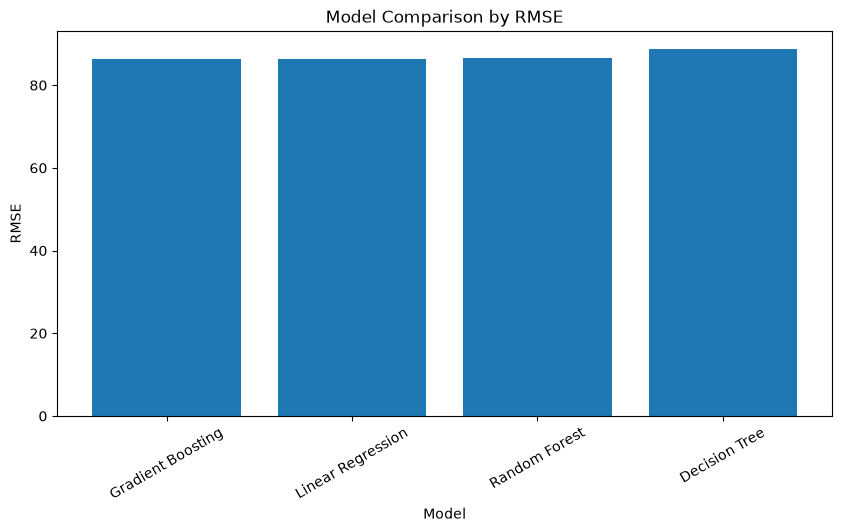

In [ ]:
results = []
trained_models = {}

for model_name, model in models.items():

    print("=" * 60)
    print("Training model:", model_name)

    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2_Score": r2
    })

    trained_models[model_name] = pipeline

    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE", ascending=True)

results_df

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()

Best parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 150}
Best CV RMSE:
85.33329711596893
Final best model: Gradient Boosting


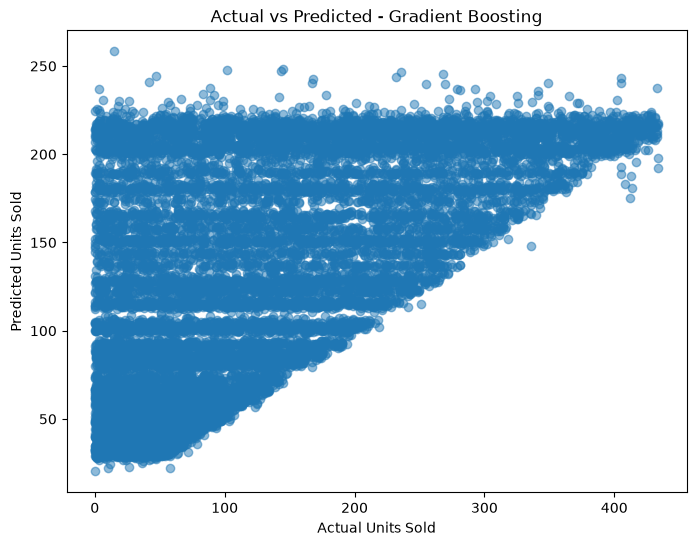

In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [10, 15],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("Best CV RMSE:")
print(-grid_search.best_score_)

#
tuned_model = grid_search.best_estimator_

y_pred_tuned = tuned_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

tuned_result = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "MAE": mae_tuned,
    "MSE": mse_tuned,
    "RMSE": rmse_tuned,
    "R2_Score": r2_tuned
}])

tuned_result

final_results_df = pd.concat([results_df, tuned_result], ignore_index=True)
final_results_df = final_results_df.sort_values(by="RMSE", ascending=True)

final_results_df

final_best_model_name = final_results_df.iloc[0]["Model"]

if final_best_model_name == "Tuned Random Forest":
    final_model = tuned_model
else:
    final_model = trained_models[final_best_model_name]

print("Final best model:", final_best_model_name)

final_predictions = final_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual_Units_Sold": y_test.values,
    "Predicted_Units_Sold": final_predictions
})

comparison_df.head(10)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, final_predictions, alpha=0.5)
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title(f"Actual vs Predicted - {final_best_model_name}")
plt.show()

In [ ]:
model_filename = "best_product_sales_prediction_model.joblib"

joblib.dump(final_model, model_filename)

print("Model saved successfully:", model_filename)

loaded_model = joblib.load(model_filename)

loaded_predictions = loaded_model.predict(X_test.head(5))

pd.DataFrame({
    "Actual": y_test.head(5).values,
    "Predicted_by_Loaded_Model": loaded_predictions
})

new_sample = X_test.head(1)

new_prediction = loaded_model.predict(new_sample)

print("Predicted Units Sold:", new_prediction[0])

new_sample

Model saved successfully: best_product_sales_prediction_model.joblib
Predicted Units Sold: 102.14861310391125


,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Ordered,Price,Discount,Weather_Condition,Holiday_Promotion,...,Seasonality,Year,Month,Day,DayOfWeek,Quarter,Is_Weekend,Discounted_Price,Price_Difference,Inventory_Level_Log
44774,S004,P0015,Electronics,West,205,95,71.15,15,Snowy,0,...,Summer,2023,3,24,4,1,0,60.4775,-0.45,5.327876
